# 3. Cohen–Sutherland Line Clipping Algorithm

**Computer Graphics LAB — Python Implementation**

## Problem Explanation


Cohen–Sutherland clips a line against a rectangular clipping window.
Each endpoint gets a 4-bit region code: TOP, BOTTOM, RIGHT, LEFT.
From the codes we can quickly accept, reject, or clip the line.


    **বাংলায় সহজভাবে:**  
    Rectangle-এর বাইরে থাকা line-এর অংশ কেটে শুধু window-এর ভিতরের অংশ রাখা হয়। 4-bit region code দিয়ে খুব দ্রুত সিদ্ধান্ত নেওয়া যায়।

## Algorithm Steps

1. Assign a 4-bit outcode to each endpoint.
2. If both outcodes are 0000, accept the line.
3. If bitwise AND of the outcodes is not 0, reject the line.
4. Otherwise find the intersection with the appropriate window boundary.
5. Replace the outside endpoint and repeat.

## Python Solution

নিচের code cell run করলে algorithm-এর result graphically দেখা যাবে।
Sample input দেওয়া আছে; চাইলে নিজের value বসিয়ে পরিবর্তন করতে পারবেন।

Clipped line: (2, 2.6, 7.5, 7)


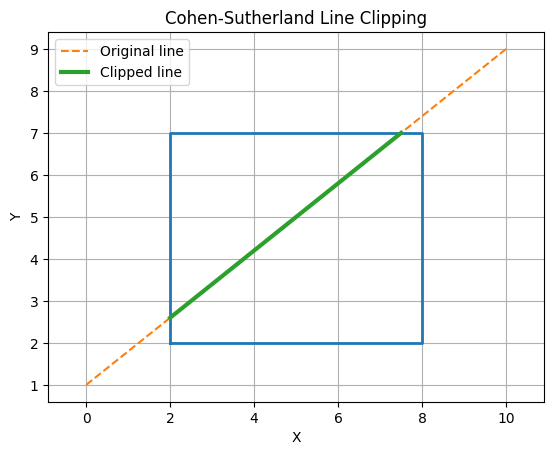

In [1]:
import matplotlib.pyplot as plt

# Clipping rectangle
xmin, ymin = 2, 2
xmax, ymax = 8, 7

# Sample line
x1, y1 = 0, 1
x2, y2 = 10, 9

INSIDE = 0
LEFT   = 1
RIGHT  = 2
BOTTOM = 4
TOP    = 8

def compute_code(x, y):
    code = INSIDE

    if x < xmin:
        code |= LEFT
    elif x > xmax:
        code |= RIGHT

    if y < ymin:
        code |= BOTTOM
    elif y > ymax:
        code |= TOP

    return code

def cohen_sutherland(x1, y1, x2, y2):
    code1 = compute_code(x1, y1)
    code2 = compute_code(x2, y2)

    while True:
        # Both points are inside
        if code1 == 0 and code2 == 0:
            return True, (x1, y1, x2, y2)

        # Both points share an outside region
        if code1 & code2:
            return False, None

        # Choose one outside point
        code_out = code1 if code1 != 0 else code2

        if code_out & TOP:
            x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)
            y = ymax

        elif code_out & BOTTOM:
            x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
            y = ymin

        elif code_out & RIGHT:
            y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
            x = xmax

        else:  # LEFT
            y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
            x = xmin

        # Replace the outside endpoint
        if code_out == code1:
            x1, y1 = x, y
            code1 = compute_code(x1, y1)
        else:
            x2, y2 = x, y
            code2 = compute_code(x2, y2)

accepted, clipped = cohen_sutherland(x1, y1, x2, y2)

# Draw clipping window
rect_x = [xmin, xmax, xmax, xmin, xmin]
rect_y = [ymin, ymin, ymax, ymax, ymin]
plt.plot(rect_x, rect_y, linewidth=2)

# Draw original line
plt.plot([x1, x2], [y1, y2], linestyle="--", label="Original line")

if accepted:
    cx1, cy1, cx2, cy2 = clipped
    print("Clipped line:", clipped)
    plt.plot([cx1, cx2], [cy1, cy2], linewidth=3, label="Clipped line")
else:
    print("Line is completely outside the window.")

plt.title("Cohen-Sutherland Line Clipping")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.show()

## What to Observe

- Code-এর শুরুতে sample input দেওয়া আছে।
- Output graph-এ original points/shape এবং final result দেখা যাবে।
- Viva-তে মূল idea, formula/decision rule, এবং algorithm-এর purpose বলতে পারলেই যথেষ্ট।